In [31]:
#--------------------------------------------------------------------------------------
# SCRIPT TO TEST READING LEVELS AND VALUE PROFILES WITH ORIGINAL SIMULATED SCENARIOS
#--------------------------------------------------------------------------------------
import torch
import pandas as pd
import numpy as np
import glob
import os
import time
import random
import transformers
import re
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scikit_posthocs as sp
from sklearn.utils import resample
from tqdm import tqdm
from sklearn.metrics import cohen_kappa_score
from itertools import combinations
from pytorch_lightning import seed_everything
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal, sem, t, ttest_ind
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
seed_everything(42)

### CHECK GPU STATUS ###
def is_notebook():
    return True if 'JPY_PARENT_PID' in os.environ else False
USE_CUDA = torch.cuda.is_available()
device = torch.device("cuda" if USE_CUDA else "cpu")
print(f'*** GPU is available: {USE_CUDA}')
print(f'*** Running off a Jupyter Notebook: {is_notebook()}')

### LOAD DATA ###
results = pd.read_csv('ReadingLevelResults_Page1.csv', header=0, encoding='cp1252')
results['Adjudicator'] = results['Adjudicator'].replace({'KA': 'Adjudicator 1', 'NB': 'Adjudicator 2', 'PH': 'Adjudicator 3', 'AK': 'Adjudicator 4', 'MSA': 'Adjudicator 5', 'PD': 'Adjudicator 6'})
print(results.head())

[rank: 0] Seed set to 42


*** GPU is available: False
*** Running off a Jupyter Notebook: True
        Type  Scenario    Adjudicator Adjudicator_Type   ReadingLevel  \
0  Simulated         1  Adjudicator 1           Expert      5th Grade   
1  Simulated         1  Adjudicator 1           Expert  8th/9th Grade   
2  Simulated         1  Adjudicator 1           Expert  College Level   
3  Simulated         2  Adjudicator 1           Expert      5th Grade   
4  Simulated         2  Adjudicator 1           Expert  8th/9th Grade   

   A1 Score  A2 Score                                           Comments  \
0         5         5                                                NaN   
1         5         5                                                NaN   
2         2         1  This patient’s quality of life is already comp...   
3         2         1  This patient faces a substantial risk of morbi...   
4         4         1                                                NaN   

   Extracted Value Score  
0       

/blue/prismap-ai-core/vnolan/conda/envs/APARI2_Models/lib/python3.12/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [3]:
#-----------------------------------------------------------------------------------------------------------
# FIRST CHECK - RESULTS OF SIMULATED DATA ARE DIFFERENT ACROSS EXPERT OR STUDENT AND ACROSS READING LEVELS
#-----------------------------------------------------------------------------------------------------------

print(f"******* Overall Results *******")
results["Combined Score"] = results["A1 Score"] + results["A2 Score"]
mean_combined_simulated = results[results["Type"] == "Simulated"].groupby("Adjudicator_Type")["Combined Score"].mean()
sd_combined_simulated = results[results["Type"] == "Simulated"].groupby("Adjudicator_Type")["Combined Score"].std()
print(mean_combined_simulated, sd_combined_simulated)
df_simulated = results[results["Type"] == "Simulated"]
group1 = df_simulated[df_simulated["Adjudicator_Type"] == "Expert"]["Combined Score"].dropna()
group2 = df_simulated[df_simulated["Adjudicator_Type"] == "Student"]["Combined Score"].dropna()
t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
n1, n2 = len(group1), len(group2)
s1, s2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
df = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2 / (n1 - 1)) + ((s2/n2)**2 / (n2 - 1)))
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {df:.2f}")

reading_levels = df_simulated["ReadingLevel"].unique()
for level in reading_levels:
    print(f"\n******* Reading Level: {level} *******")
    df_level = df_simulated[df_simulated["ReadingLevel"] == level]    
    group1 = df_level[df_level["Adjudicator_Type"] == "Expert"]["Combined Score"].dropna()
    group2 = df_level[df_level["Adjudicator_Type"] == "Student"]["Combined Score"].dropna()    
    mean_combined = df_level.groupby("Adjudicator_Type")["Combined Score"].mean()
    sd_combined = df_level.groupby("Adjudicator_Type")["Combined Score"].std()    
    print(f"Mean Combined Scores:\n{mean_combined}")
    print(f"Standard Deviations:\n{sd_combined}")    
    t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
    n1, n2 = len(group1), len(group2)
    s1, s2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    df = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2 / (n1 - 1)) + ((s2/n2)**2 / (n2 - 1)))
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Degrees of Freedom: {df:.2f}") 


******* Overall Results *******
Adjudicator_Type
Expert     7.971429
Student    8.177778
Name: Combined Score, dtype: float64 Adjudicator_Type
Expert     2.000591
Student    1.907114
Name: Combined Score, dtype: float64
T-statistic: -1.3250
P-value: 0.1856
Degrees of Freedom: 626.57

******* Reading Level: 5th Grade *******
Mean Combined Scores:
Adjudicator_Type
Expert     8.057143
Student    8.180952
Name: Combined Score, dtype: float64
Standard Deviations:
Adjudicator_Type
Expert     1.935640
Student    1.790901
Name: Combined Score, dtype: float64
T-statistic: -0.4811
P-value: 0.6310
Degrees of Freedom: 206.76

******* Reading Level: 8th/9th Grade *******
Mean Combined Scores:
Adjudicator_Type
Expert     8.028571
Student    8.285714
Name: Combined Score, dtype: float64
Standard Deviations:
Adjudicator_Type
Expert     1.938760
Student    1.864209
Name: Combined Score, dtype: float64
T-statistic: -0.9797
P-value: 0.3284
Degrees of Freedom: 207.68

******* Reading Level: College Level 

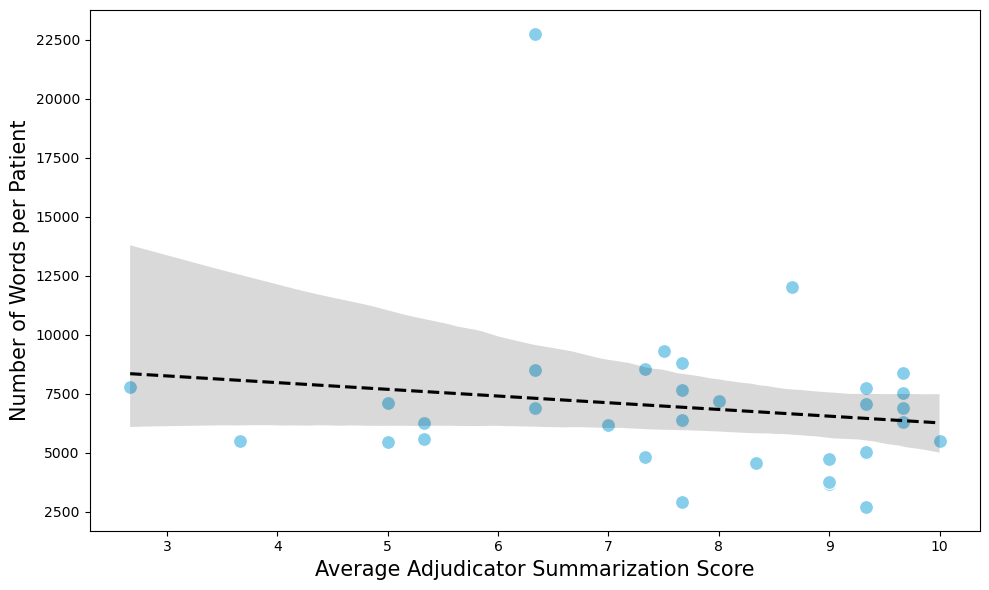

Pearson correlation:  r = -0.157, p = 3.670e-01
Spearman correlation: r = -0.144, p = 4.077e-01
Bootstrapped mean SummaryScore: 7.72
95% CI: (7.09, 8.63)


In [6]:
#--------------------------------------------------------
## 1) NOTE SUMMARY: NUMBER OF WORDS VERSUS SUMARIZATION SCORE
#--------------------------------------------------------
notes = pd.read_csv('ReadingLevelResults_Page2.csv', header = 0)
notes = notes.dropna(subset=['SummaryScore'])
grouped = notes.groupby(["Adjudicator", "Note Length"], as_index=False)["SummaryScore"].mean()
avg_df = notes.groupby("Note Length", as_index=False)["SummaryScore"].mean()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=avg_df, y="Note Length", x="SummaryScore", s=100, color='skyblue')
sns.regplot(data=avg_df, y="Note Length", x="SummaryScore", scatter=False, color="black", line_kws={"linestyle": "dashed"})
plt.ylabel("Number of Words per Patient", size = 15)
plt.xlabel("Average Adjudicator Summarization Score", size = 15)
plt.tight_layout()
plt.show()

x = avg_df["Note Length"]
y = avg_df["SummaryScore"]
pearson_corr, pearson_p = pearsonr(x, y)
spearman_corr, spearman_p = spearmanr(x, y)
print(f"Pearson correlation:  r = {pearson_corr:.3f}, p = {pearson_p:.3e}")
print(f"Spearman correlation: r = {spearman_corr:.3f}, p = {spearman_p:.3e}")

# Bootstrap Means
n_boot = 1000
boot_means = []
adjudicators = notes['Adjudicator'].unique()
for _ in range(n_boot):
    sampled_adjudicators = np.random.choice(adjudicators, size=len(adjudicators), replace=True)
    sample_df = pd.concat([notes[notes['Adjudicator'] == adj] for adj in sampled_adjudicators])
    boot_means.append(sample_df['SummaryScore'].mean())
mean_score = np.mean(boot_means)
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)
print(f"Bootstrapped mean SummaryScore: {mean_score:.2f}")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

In [34]:
#--------------------------------------------------------------------------
# 2) VALUE EXTRACTION AND READING LEVEL ASSESSMENT
#--------------------------------------------------------------------------
results_real = results[results['Type'] == 'Real'].copy()
results_real['Unit'] = results_real['Scenario'].astype(str) + "_" + results_real['Adjudicator']
units = results_real['Unit'].unique()
n_boot = 1000
boot_means = []
boot_means_by_level = {level: [] for level in results_real['ReadingLevel'].unique()}
for _ in range(n_boot):
    sampled_units = np.random.choice(units, size=len(units), replace=True)
    sample_df = pd.concat([results_real[results_real['Unit'] == u] for u in sampled_units])
    boot_means.append(sample_df['Extracted Value Score'].mean())
    for level in boot_means_by_level.keys():
        subset = sample_df[sample_df['ReadingLevel'] == level]['Extracted Value Score']
        if len(subset) > 0:
            boot_means_by_level[level].append(subset.mean())
mean_val = np.mean(boot_means)
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)
print(f"Overall bootstrapped mean: {mean_val:.2f}, 95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")


     Type  Scenario    Adjudicator Adjudicator_Type   ReadingLevel  A1 Score  \
630  Real         1  Adjudicator 4          Student      5th Grade         4   
631  Real         1  Adjudicator 4          Student  8th/9th Grade         4   
632  Real         1  Adjudicator 4          Student  College Level         4   
633  Real         2  Adjudicator 4          Student      5th Grade         5   
634  Real         2  Adjudicator 4          Student  8th/9th Grade         5   

     A2 Score Comments  Extracted Value Score             Unit  
630         3      NaN                    5.0  1_Adjudicator 4  
631         4      NaN                    5.0  1_Adjudicator 4  
632         4      NaN                    5.0  1_Adjudicator 4  
633         4      NaN                    5.0  2_Adjudicator 4  
634         5      NaN                    6.0  2_Adjudicator 4  
Overall bootstrapped mean: 7.64, 95% CI: (7.26, 7.97)


           mean              ci
A1 Score  3.695  (3.557, 3.836)
A2 Score   3.93  (3.763, 4.086)
           mean              ci
A1 Score  4.248  (4.154, 4.357)
A2 Score  3.827  (3.719, 3.943)


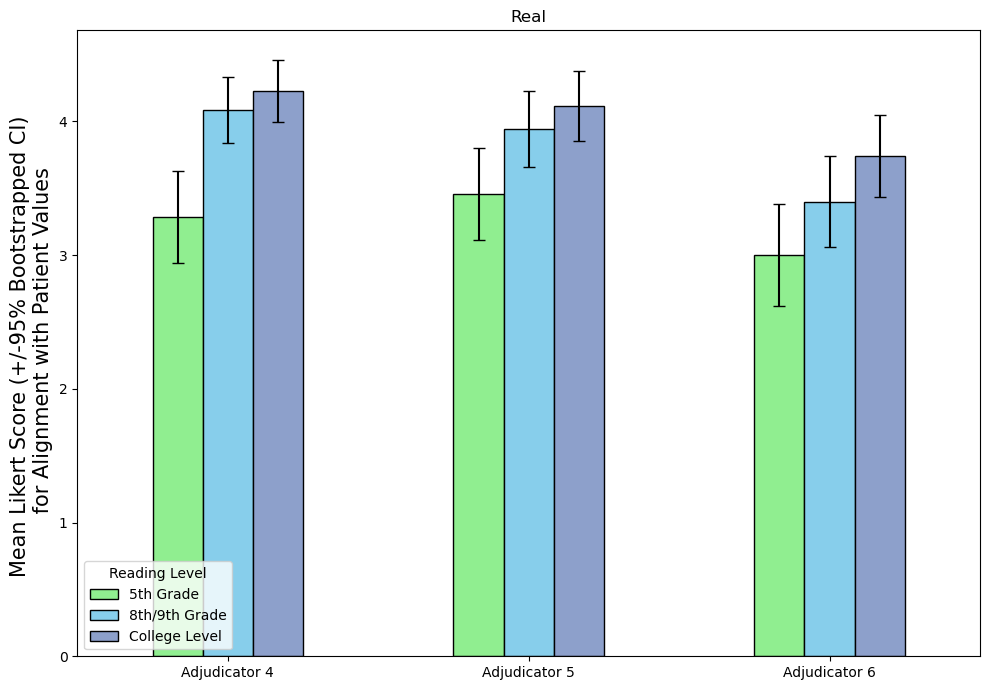

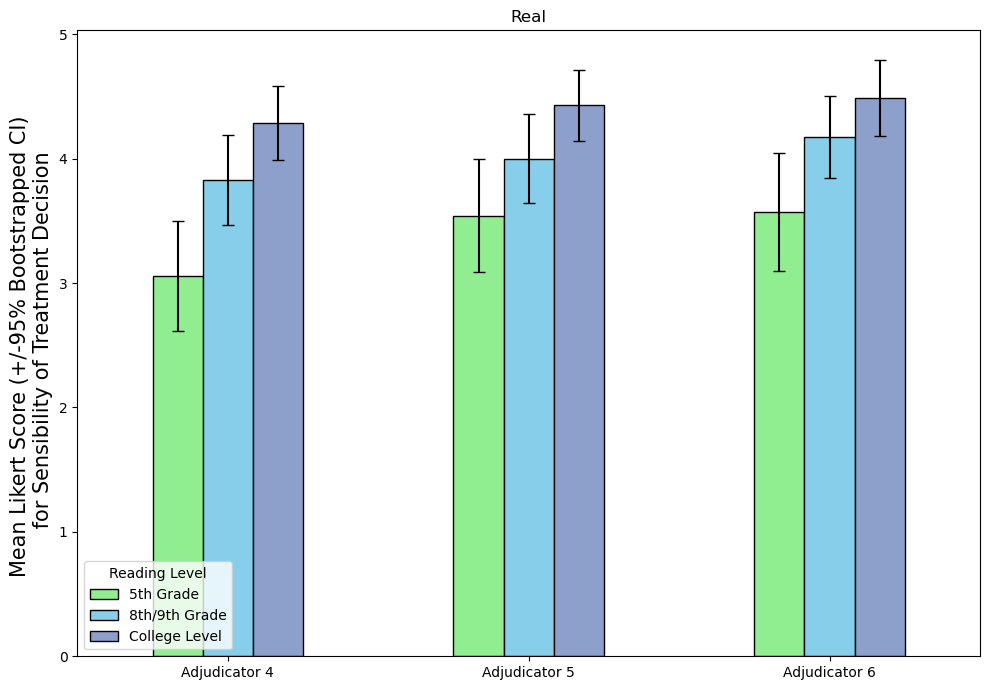

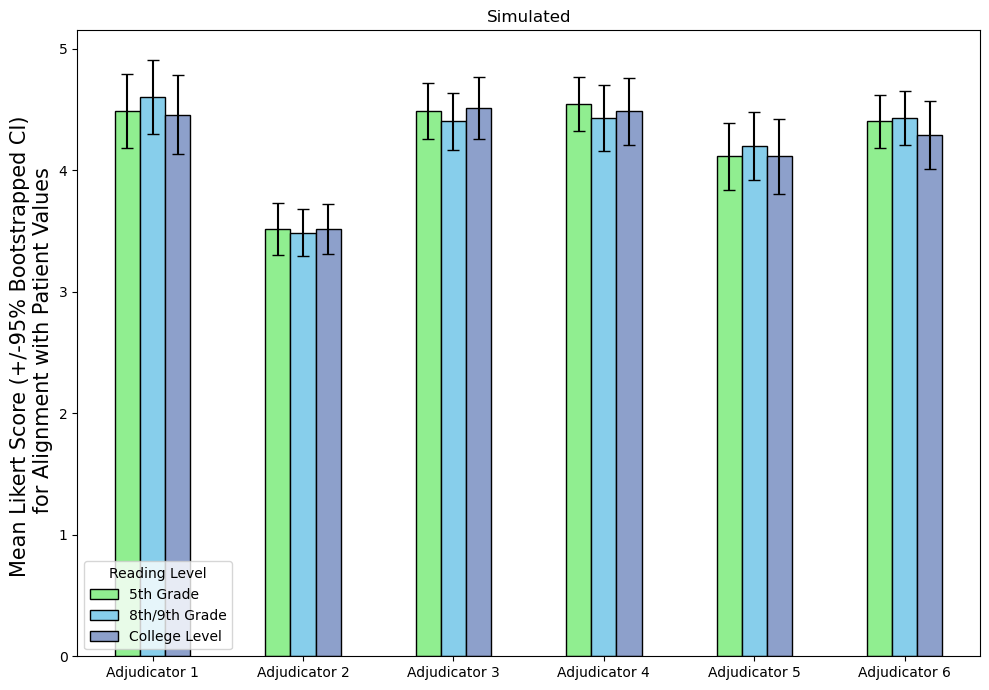

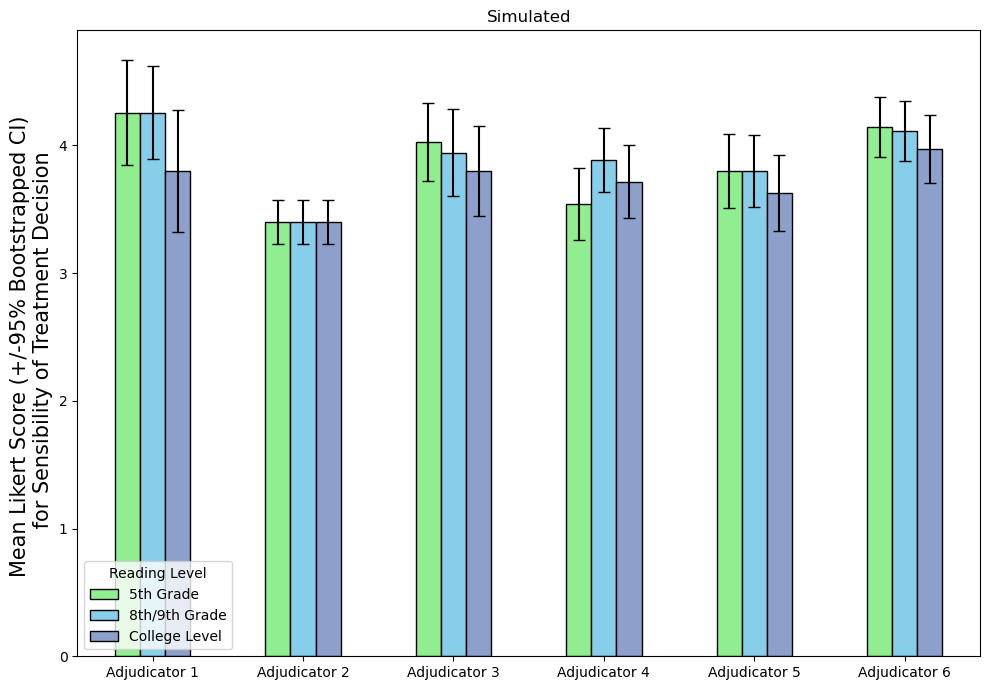

In [16]:
#-----------------------------------------------------------------------------------------------------------
## RESULTS OF OVERALL ADJUDICATIONS - MEAN AND CONFIDENCE INTERVALS #
#-----------------------------------------------------------------------------------------------------------
def clustered_bootstrap_ci(df, cluster_cols, value_col, n_iterations=1000, ci=95):
    rng = np.random.default_rng()
    cluster_ids = df.groupby(cluster_cols).ngroup().unique()  
    n_clusters = len(cluster_ids)
    boot_means = []
    for _ in range(n_iterations):
        sampled_clusters = rng.choice(cluster_ids, size=n_clusters, replace=True)
        sampled_df = df[df.groupby(cluster_cols).ngroup().isin(sampled_clusters)]
        boot_means.append(sampled_df[value_col].mean())
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return df[value_col].mean(), (lower, upper)

ci_results = {}
results_real = results[results['Type'] == 'Real'].copy()
for score_col in ['A1 Score', 'A2 Score']:
    mean, (low, high) = clustered_bootstrap_ci(results_real, cluster_cols=['Scenario','Adjudicator'], value_col=score_col, n_iterations=1000)
    ci_results[score_col] = {'mean': round(mean,3), 'ci': (round(low,3), round(high,3))}
print(pd.DataFrame(ci_results).T)

ci_results_sim = {}
results_sim = results[results['Type'] == 'Simulated'].copy()
for score_col in ['A1 Score', 'A2 Score']:
    mean, (low, high) = clustered_bootstrap_ci(results_sim, cluster_cols=['Scenario','Adjudicator'], value_col=score_col, n_iterations=1000)
    ci_results_sim[score_col] = {'mean': round(mean,3), 'ci': (round(low,3), round(high,3))}
print(pd.DataFrame(ci_results_sim).T)

def plot_with_boot_ci(df, score_column, ylabel):
    unique_types = df['Type'].unique()
    for t in unique_types:
        df_filtered = df[df['Type'] == t].copy()
        adjudicators = df_filtered['Adjudicator'].unique()
        reading_levels = df_filtered['ReadingLevel'].unique()        
        plot_data = []
        ci_data = []
        for adj in adjudicators:
            means_row = []
            ci_row = []
            for rl in reading_levels:
                subset = df_filtered[(df_filtered['Adjudicator'] == adj) & (df_filtered['ReadingLevel'] == rl)]
                if subset.empty:
                    means_row.append(np.nan)
                    ci_row.append((np.nan, np.nan))
                    continue
                mean_val, (ci_low, ci_high) = clustered_bootstrap_ci(subset, cluster_cols=['Scenario','Adjudicator'], value_col=score_column)
                means_row.append(mean_val)
                ci_row.append((ci_low, ci_high))
            plot_data.append(means_row)
            ci_data.append(ci_row)
        plot_df = pd.DataFrame(plot_data, index=adjudicators, columns=reading_levels)
        ci_lower = pd.DataFrame([[ci_pair[0] for ci_pair in row] for row in ci_data], index=adjudicators, columns=reading_levels)
        ci_upper = pd.DataFrame([[ci_pair[1] for ci_pair in row] for row in ci_data], index=adjudicators, columns=reading_levels)
        ci_error = ci_upper - plot_df        
        ax = plot_df.plot(kind='bar', figsize=(10, 7), yerr=ci_error, capsize=4, color=['lightgreen', 'skyblue', '#8da0cb'], edgecolor='black')        
        plt.xlabel('')
        plt.ylabel(ylabel, size=15)
        plt.title(f"{t}")
        plt.xticks(rotation=0)
        plt.legend(title='Reading Level', loc='lower left', bbox_to_anchor=(0, 0))
        plt.tight_layout()
        plt.show()

plot_with_boot_ci(results_real, 'A1 Score', 'Mean Likert Score (+/-95% Bootstrapped CI) \n for Alignment with Patient Values')
plot_with_boot_ci(results_real, 'A2 Score', 'Mean Likert Score (+/-95% Bootstrapped CI) \n for Sensibility of Treatment Decision')
plot_with_boot_ci(results_sim, 'A1 Score', 'Mean Likert Score (+/-95% Bootstrapped CI) \n for Alignment with Patient Values')
plot_with_boot_ci(results_sim, 'A2 Score', 'Mean Likert Score (+/-95% Bootstrapped CI) \n for Sensibility of Treatment Decision')

     Type  Scenario    Adjudicator   ReadingLevel  Extracted Value Score  \
630  Real         1  Adjudicator 4      5th Grade                    5.0   
631  Real         1  Adjudicator 4  8th/9th Grade                    5.0   
632  Real         1  Adjudicator 4  College Level                    5.0   
633  Real         2  Adjudicator 4      5th Grade                    5.0   
634  Real         2  Adjudicator 4  8th/9th Grade                    6.0   

    Score_Type  Score  
630   A1 Score      4  
631   A1 Score      4  
632   A1 Score      4  
633   A1 Score      5  
634   A1 Score      5  
                             Mixed Linear Model Regression Results
Model:                           MixedLM               Dependent Variable:               Score 
No. Observations:                630                   Method:                           REML  
No. Groups:                      3                     Scale:                            1.7390
Min. group size:                 210        

/blue/prismap-ai-core/vnolan/conda/envs/APARI2_Models/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/blue/prismap-ai-core/vnolan/conda/envs/APARI2_Models/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/blue/prismap-ai-core/vnolan/conda/envs/APARI2_Models/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/blue/prismap-ai-core/vnolan/conda/envs/APARI2_Models/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/blue/prismap-ai-core/vnolan/conda/envs/APARI2_Models/lib/python3.12/site-packages/stats

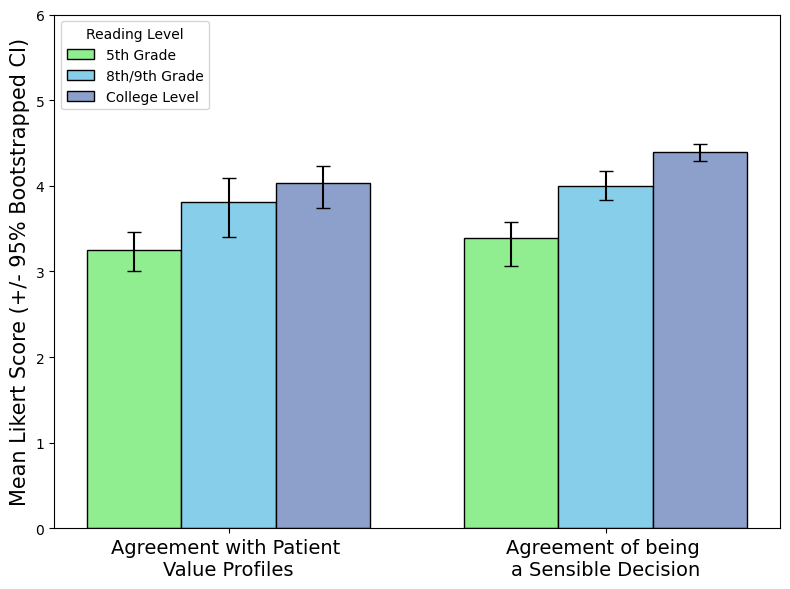

In [35]:
#-----------------------------------------------------------------------------------------------------------
## PLOTTING ACROSS ADJUDICATORS - LIKERT
#-----------------------------------------------------------------------------------------------------------
results2 = pd.melt(results, id_vars=['Type', 'Scenario', 'Adjudicator', 'ReadingLevel','Extracted Value Score'], 
                    value_vars=['A1 Score', 'A2 Score'], 
                    var_name='Score_Type', value_name='Score')
results2 = results2[results2['Type'] == 'Real']  # change to Real or Simulated
print(results2.head())

# TEST FOR N0RMALITY - NOT NORMAL
'''
fifth_grade_scores = results2[results2['ReadingLevel'] == '5th Grade']['Score']
eighth_ninth_scores = results2[results2['ReadingLevel'] == '8th/9th Grade']['Score']
college_scores = results2[results2['ReadingLevel'] == 'College Level']['Score']
sns.histplot(fifth_grade_scores, kde=True, bins=10, color='blue', label='5th Grade')
sns.histplot(eighth_ninth_scores, kde=True, bins=10, color='orange', label='8th/9th Grade')
sns.histplot(college_scores, kde=True, bins=10, color='green', label='College Level')
plt.legend()
plt.show()'''

# SIGNIFICANT DIFFERENCES ACROSS READING LEVELS AND SCORES
import statsmodels.formula.api as smf
lme = smf.mixedlm("Score ~ ReadingLevel * Score_Type",
                  data=results2,
                  groups=results2["Adjudicator"])
lme_fit = lme.fit()
print(lme_fit.summary())

# CALCULATE CLUSTERED BOOTSTRAP CI
def clustered_bootstrap_ci(df, cluster_col, value_col, n_iterations=1000, ci=95, random_seed=None):
    rng = np.random.default_rng(random_seed)
    clusters = df[cluster_col].unique()
    n_clusters = len(clusters)
    boot_means = []
    for _ in range(n_iterations):
        sampled_clusters = rng.choice(clusters, size=n_clusters, replace=True)
        sampled_df = df[df[cluster_col].isin(sampled_clusters)]
        cluster_avg = sampled_df.groupby(cluster_col)[value_col].mean()
        boot_means.append(cluster_avg.mean())
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return df.groupby(cluster_col)[value_col].mean().mean(), (lower, upper)

boot_results = []
for score_type in results2['Score_Type'].unique():
    for rl in results2['ReadingLevel'].unique():
        subset = results2[(results2['ReadingLevel'] == rl) & (results2['Score_Type'] == score_type)]
        mean_val, (ci_lower, ci_upper) = clustered_bootstrap_ci(
            subset, cluster_col='Adjudicator', value_col='Score', n_iterations=1000)
        boot_results.append({
            'ReadingLevel': rl,
            'Score_Type': score_type,
            'Mean': mean_val,
            'CI Lower': ci_lower,
            'CI Upper': ci_upper})
boot_df = pd.DataFrame(boot_results)
boot_df['error_lower'] = boot_df['Mean'] - boot_df['CI Lower']
boot_df['error_upper'] = boot_df['CI Upper'] - boot_df['Mean']
label_map = {
    'A1 Score': 'Agreement with Patient \nValue Profiles',
    'A2 Score': 'Agreement of being \na Sensible Decision'}
boot_df['Score_Label'] = boot_df['Score_Type'].map(label_map)

# PLOT MEANS ACROSS READING LEVEL WITH BOOTSTRAPPED CI
fig, ax = plt.subplots(figsize=(8, 6))
reading_levels = boot_df['ReadingLevel'].unique()
colors = ['lightgreen', 'skyblue', '#8da0cb']
bar_width = 0.25
x_labels = boot_df['Score_Label'].unique()
x = np.arange(len(x_labels))
for i, rl in enumerate(reading_levels):
    subset = boot_df[boot_df['ReadingLevel'] == rl]
    x_positions = x + i * bar_width
    ax.bar(
        x_positions,
        subset['Mean'],
        yerr=[subset['error_lower'], subset['error_upper']],
        capsize=5,
        color=colors[i],
        label=rl,
        width=bar_width,
        edgecolor='black')
center_positions = x + (bar_width * (len(reading_levels) - 1) / 2)
ax.set_xticks(center_positions)
ax.set_xticklabels(x_labels, size=14)
ax.set_ylabel('Mean Likert Score (+/- 95% Bootstrapped CI)', size=15)
ax.set_ylim(0, 6)
ax.legend(title='Reading Level', loc='upper left')
plt.tight_layout()
plt.show()

                 Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   ExtractedValueScore
No. Observations:   630       Method:               REML               
No. Groups:         3         Scale:                2.8810             
Min. group size:    210       Log-Likelihood:       -1233.9436         
Max. group size:    210       Converged:            Yes                
Mean group size:    210.0                                              
-----------------------------------------------------------------------
                              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     7.000    0.657 10.650 0.000  5.712  8.288
ReadingLevel[T.8th/9th Grade] 0.781    0.166  4.715 0.000  0.456  1.106
ReadingLevel[T.College Level] 1.143    0.166  6.900 0.000  0.818  1.468
Adjudicator Var               1.255    0.748                           



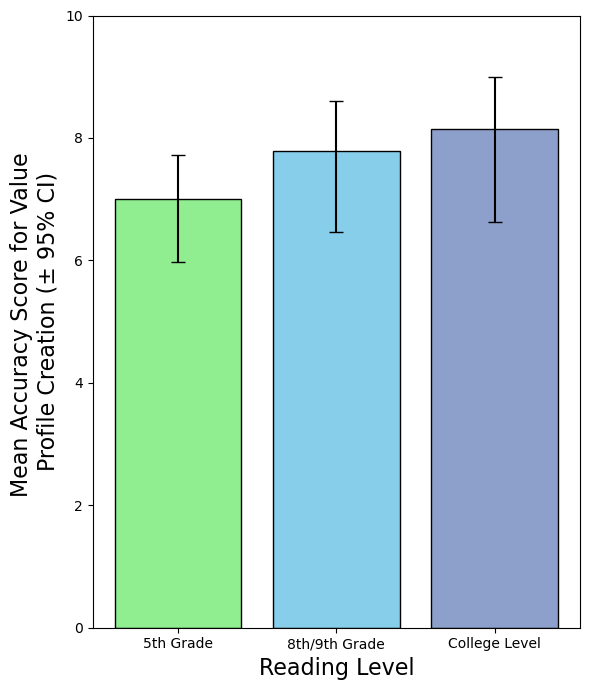

In [48]:
#-----------------------------------------------------------------------------------------------------------
## PLOTTING ACROSS ADJUDICATORS - VALUE PROFILE ACCURACY
#-----------------------------------------------------------------------------------------------------------
results2 = pd.melt(results, id_vars=['Type', 'Scenario', 'Adjudicator', 'ReadingLevel','Extracted Value Score'], 
                    value_vars=['A1 Score', 'A2 Score'], 
                    var_name='Score_Type', value_name='Score')
    results2 = results2[results2['Type'] == 'Real']  # change to Real or Simulated
results2 = results2.rename(columns={'Extracted Value Score': 'ExtractedValueScore'})

model = smf.mixedlm("ExtractedValueScore ~ ReadingLevel",
                    data=results2,
                    groups="Adjudicator")
result = model.fit()
print(result.summary())

def clustered_bootstrap_ci(df, cluster_col, value_col, n_iterations=1000, ci=95):
    rng = np.random.default_rng()
    clusters = df[cluster_col].unique()
    n_clusters = len(clusters)
    boot_means = []
    for _ in range(n_iterations):
        sampled_clusters = rng.choice(clusters, size=n_clusters, replace=True)
        sampled_df = df[df[cluster_col].isin(sampled_clusters)]
        cluster_avg = sampled_df.groupby(cluster_col)[value_col].mean()
        boot_means.append(cluster_avg.mean())
    lower = np.percentile(boot_means, (100 - ci)/2)
    upper = np.percentile(boot_means, 100 - (100 - ci)/2)
    return df[value_col].mean(), (lower, upper)

boot_results = []
for rl in results2["ReadingLevel"].unique():
    subset = results2[results2["ReadingLevel"] == rl]
    mean_val, (ci_lower, ci_upper) = clustered_bootstrap_ci(
        subset,
        cluster_col="Adjudicator",
        value_col="ExtractedValueScore",
        n_iterations=1000)
    boot_results.append({
        "ReadingLevel": rl,
        "Mean": mean_val,
        "CI Lower": ci_lower,
        "CI Upper": ci_upper})
boot_df_ev = pd.DataFrame(boot_results)
boot_df_ev['error_lower'] = boot_df_ev['Mean'] - boot_df_ev['CI Lower']
boot_df_ev['error_upper'] = boot_df_ev['CI Upper'] - boot_df_ev['Mean']

plt.figure(figsize=(6, 7))
x = np.arange(len(boot_df_ev))
colors = ["lightgreen", "skyblue", "#8da0cb"]
plt.bar(
    x,
    boot_df_ev["Mean"],
    yerr=[boot_df_ev["error_lower"], boot_df_ev["error_upper"]],
    capsize=5,
    color=colors,
    edgecolor="black")
plt.xticks(x, boot_df_ev["ReadingLevel"])
plt.ylabel("Mean Accuracy Score for Value \nProfile Creation (± 95% CI)", fontsize=16)
plt.xlabel("Reading Level", fontsize=16)
plt.ylim(0, 10)  # adjust if necessary
plt.tight_layout()
plt.show()


In [6]:
# ---------------------------------------------------------------------
# INTERRATER RELIABILITY
# ---------------------------------------------------------------------
def fleiss_kappa(matrix):
    N, k = matrix.shape
    n_raters = np.sum(matrix[0]) 
    p = np.sum(matrix, axis=0) / (N * n_raters)
    P = (np.sum(matrix**2, axis=1) - n_raters) / (n_raters * (n_raters - 1))
    Pbar = np.mean(P)       # observed agreement
    Pe = np.sum(p**2)       # expected agreement
    print(Pbar, Pe)
    return (Pbar - Pe) / (1 - Pe) if (1 - Pe) != 0 else np.nan

def to_fleiss_matrix(df):
    categories = np.unique(df.values[~pd.isna(df.values)])  # unique rating categories
    matrix = []
    for _, row in df.iterrows():
        counts = [np.sum(row == cat) for cat in categories]
        matrix.append(counts)
    return np.array(matrix)

def process_and_compute_fleiss(results, study_type, score_type):
    results_long = pd.melt(
        results,
        id_vars=['Type', 'Scenario', 'Adjudicator', 'ReadingLevel'],
        value_vars=['A1 Score', 'A2 Score'],
        var_name='Score_Type',
        value_name='Score')
    score_data = results_long[
        (results_long['Score_Type'] == score_type) &
        (results_long['Type'] == study_type)]
    score_data = score_data.sort_values(['Scenario', 'Adjudicator'])
    score_data['item_id'] = score_data.groupby(['Scenario', 'Adjudicator']).cumcount()
    score_matrix = score_data.pivot_table(
        index=['Scenario', 'item_id'],
        columns='Adjudicator',
        values='Score')
    score_matrix = score_matrix.dropna(thresh=2)
    fleiss_mat = to_fleiss_matrix(score_matrix)
    kappa = fleiss_kappa(fleiss_mat)
    print(f"Fleiss' Kappa for {study_type} - {score_type}: {kappa:.4f}")
    return kappa

process_and_compute_fleiss(results, 'Simulated', 'A1 Score')
process_and_compute_fleiss(results, 'Simulated', 'A2 Score')
process_and_compute_fleiss(results, 'Real', 'A1 Score')
process_and_compute_fleiss(results, 'Real', 'A2 Score')